In [1]:
# ============================================
# PCA AND CLUSTERING ANALYSIS ON WINE DATASET
# ============================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score


In [3]:
# ============================================
# TASK 1: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

# Load Dataset
df = pd.read_csv("wine.csv")

# Display first 5 rows
print("First 5 Rows:")
print(df.head())

First 5 Rows:
   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
0           0.28             2.29   5.64  1.04      3.92     1065  
1           0.26             1.28   4.38  1.05      3.40     1050  
2           0.30             2.81   5.68  1.03      3.17     1185  
3           0.24             2.18   7.80  0.86      3.45     1480  
4           0.39             1.82   4.32  1.04      2.93      735  


In [4]:
# Dataset Information
print("\nDataset Info:")
print(df.info())

# Statistical Summary
print("\nStatistical Summary:")
print(df.describe())

# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None

Statistical Summary:
             Type     Alcohol       Malic         Ash  Alcalinity

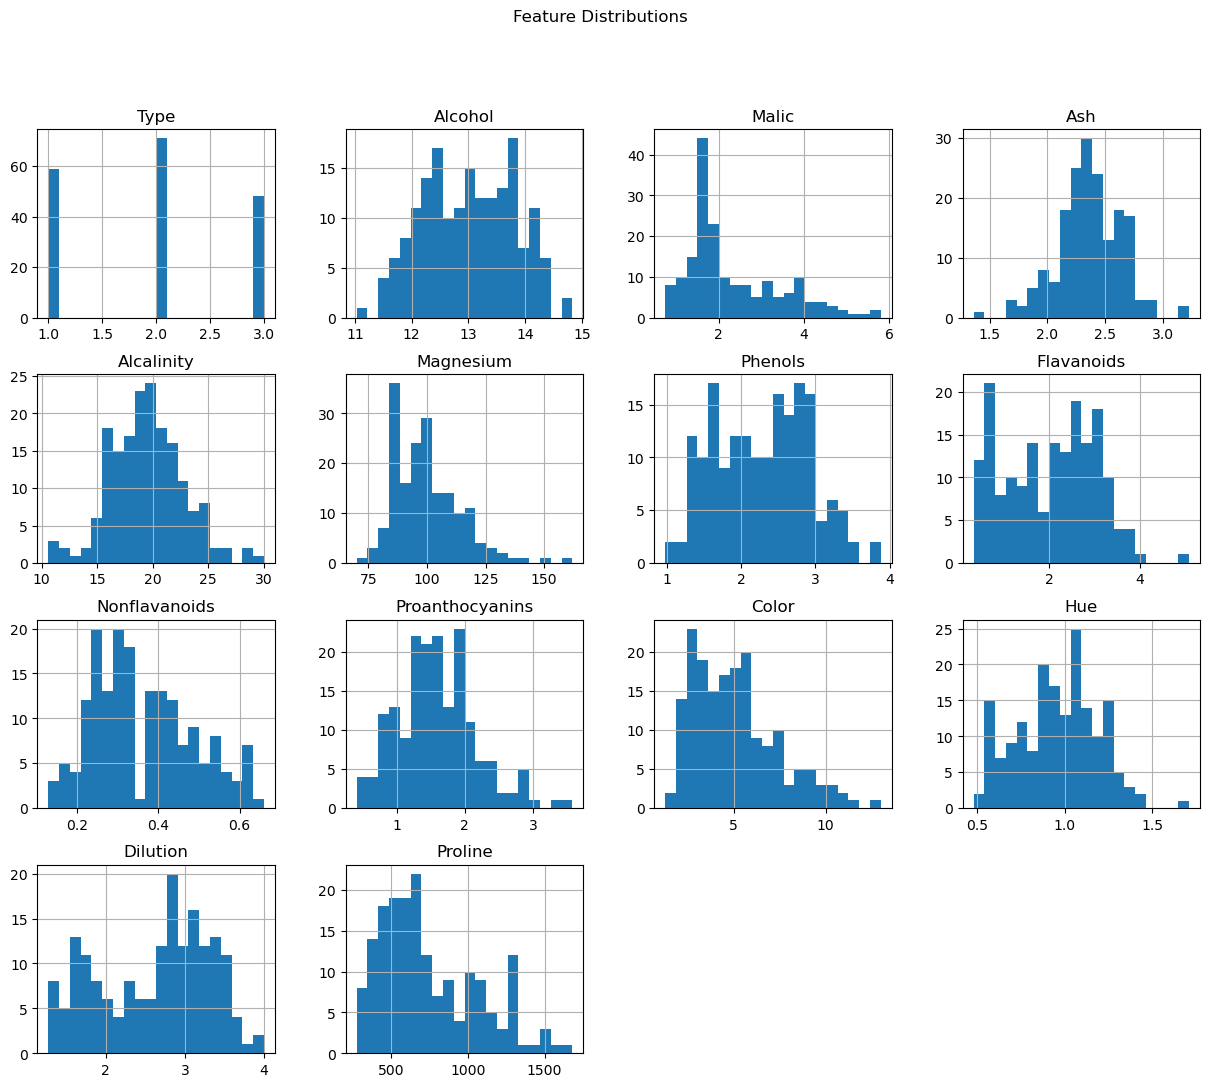

In [5]:
# --------------------------------------------
# Histograms
# --------------------------------------------
df.hist(figsize=(15, 12), bins=20)
plt.suptitle("Feature Distributions")
plt.show()

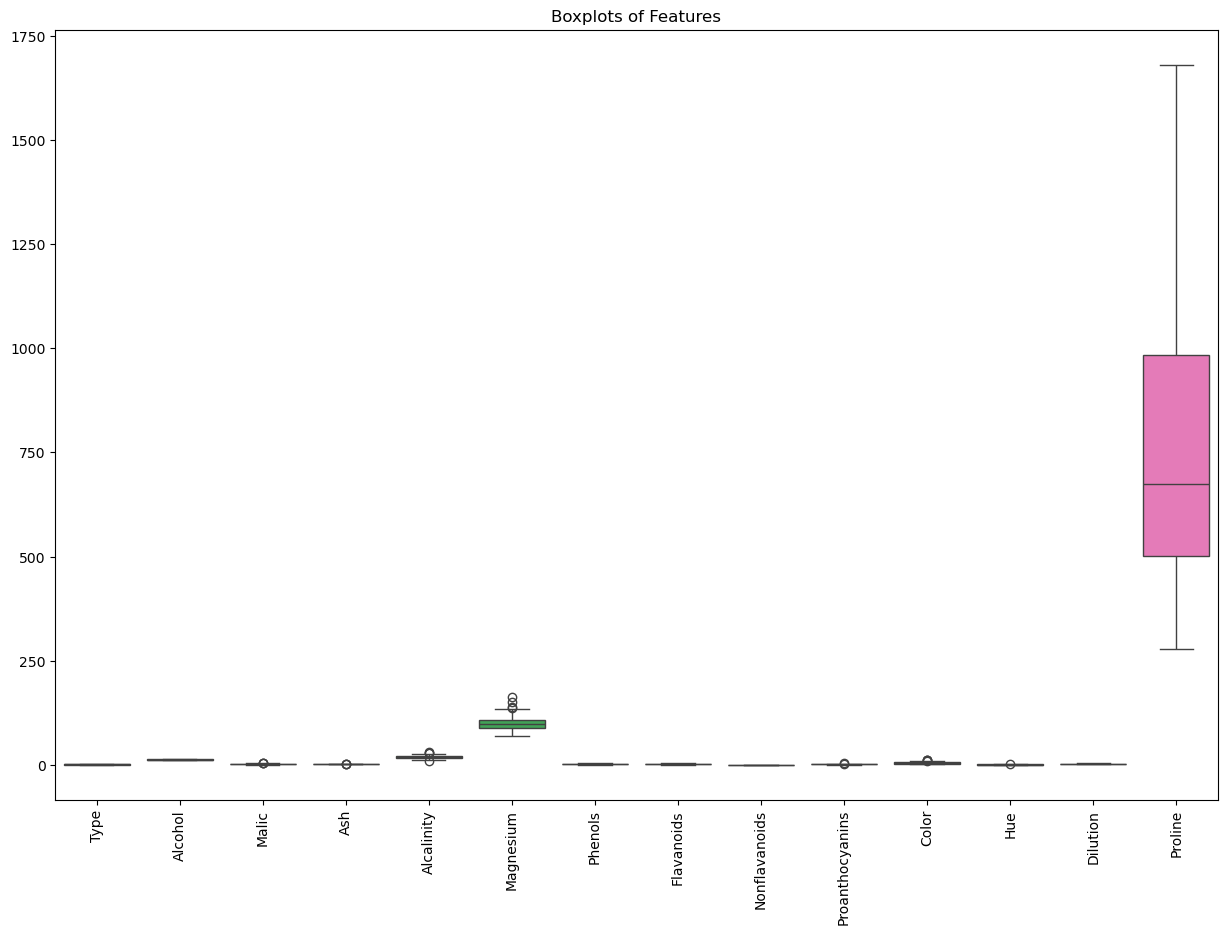

In [6]:
# --------------------------------------------
# Boxplots
# --------------------------------------------
plt.figure(figsize=(15,10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplots of Features")
plt.show()

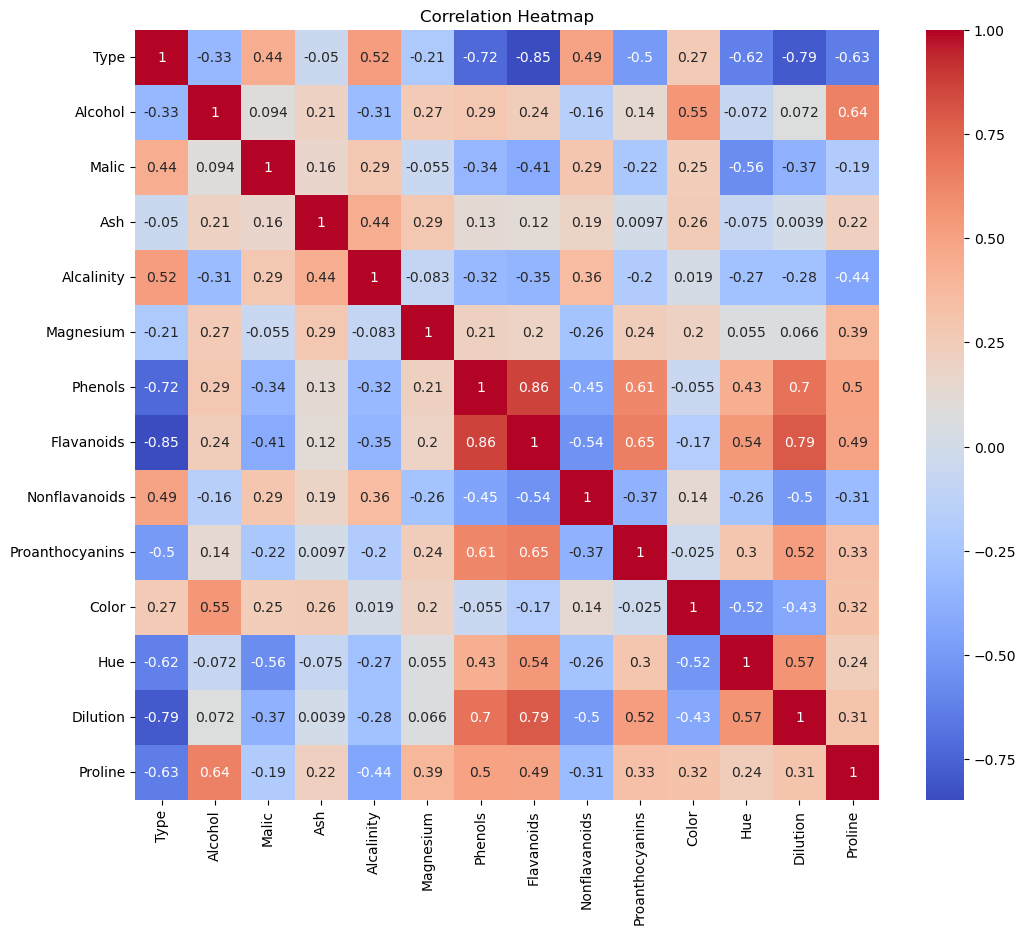

In [7]:
# --------------------------------------------
# Correlation Heatmap
# --------------------------------------------
plt.figure(figsize=(12,10))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [8]:
# ============================================
# TASK 2: DIMENSIONALITY REDUCTION WITH PCA
# ============================================

# --------------------------------------------
# Standardize the Data
# --------------------------------------------
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [9]:
# --------------------------------------------
# Apply PCA
# --------------------------------------------
pca = PCA()

pca_data = pca.fit_transform(scaled_data)

# Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_

print("\nExplained Variance Ratio:")
print(explained_variance)



Explained Variance Ratio:
[0.39542486 0.17836259 0.10329102 0.06627984 0.06267875 0.0480556
 0.03955707 0.02500244 0.02103871 0.01873615 0.01613203 0.01205691
 0.00925458 0.00412945]


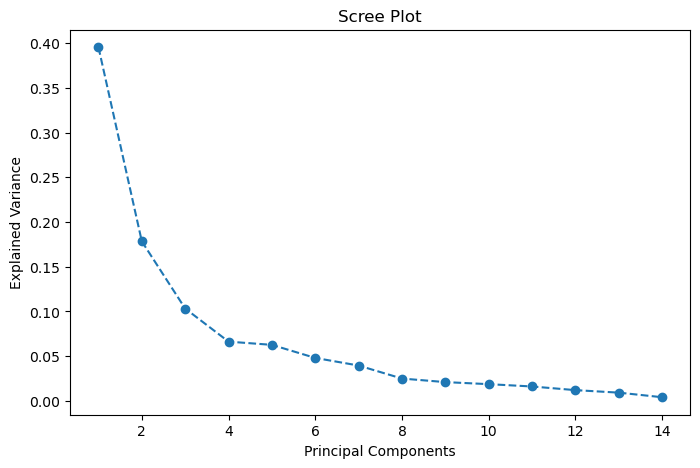

In [10]:
# --------------------------------------------
# Scree Plot
# --------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(range(1, len(explained_variance)+1),
         explained_variance,
         marker='o',
         linestyle='--')

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.show()

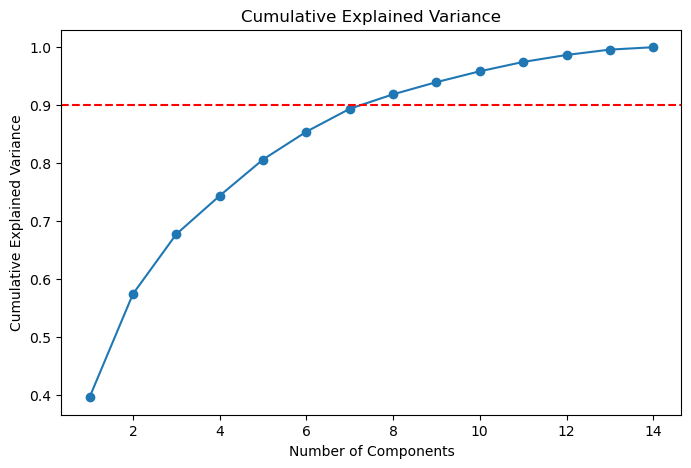

In [11]:
# --------------------------------------------
# Cumulative Explained Variance
# --------------------------------------------
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))

plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance,
         marker='o')

plt.axhline(y=0.90, color='r', linestyle='--')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.show()

In [12]:
# --------------------------------------------
# Select Optimal Number of Components
# --------------------------------------------
n_components = np.argmax(cumulative_variance >= 0.90) + 1

print("\nOptimal Number of Components:", n_components)

# --------------------------------------------
# Transform Data using Selected Components
# --------------------------------------------
pca_final = PCA(n_components=n_components)

pca_transformed = pca_final.fit_transform(scaled_data)

print("\nShape of PCA Transformed Data:")
print(pca_transformed.shape)


Optimal Number of Components: 8

Shape of PCA Transformed Data:
(178, 8)


In [13]:
# ============================================
# TASK 3: CLUSTERING WITH ORIGINAL DATA
# ============================================

# --------------------------------------------
# KMeans Clustering
# --------------------------------------------
kmeans_original = KMeans(n_clusters=3,
                         random_state=42)

original_clusters = kmeans_original.fit_predict(scaled_data)


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [14]:
# --------------------------------------------
# Evaluation Metrics
# --------------------------------------------
silhouette_original = silhouette_score(scaled_data,
                                       original_clusters)

db_original = davies_bouldin_score(scaled_data,
                                   original_clusters)

print("\nOriginal Data Clustering Metrics")
print("Silhouette Score:", silhouette_original)
print("Davies-Bouldin Index:", db_original)


Original Data Clustering Metrics
Silhouette Score: 0.30648398324833453
Davies-Bouldin Index: 1.315707552261773


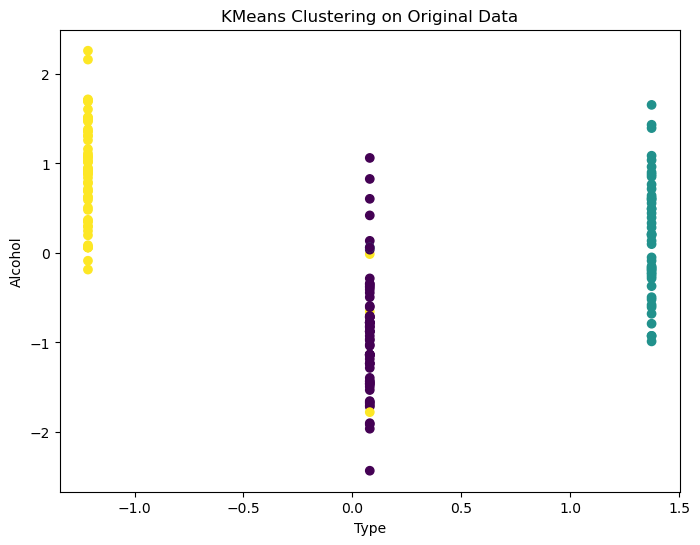

In [15]:
# --------------------------------------------
# Visualization (Using First Two Features)
# --------------------------------------------
plt.figure(figsize=(8,6))

plt.scatter(scaled_data[:,0],
            scaled_data[:,1],
            c=original_clusters,
            cmap='viridis')

plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("KMeans Clustering on Original Data")
plt.show()


In [16]:
# ============================================
# TASK 4: CLUSTERING WITH PCA DATA
# ============================================

# --------------------------------------------
# KMeans on PCA Data
# --------------------------------------------
kmeans_pca = KMeans(n_clusters=3,
                    random_state=42)

pca_clusters = kmeans_pca.fit_predict(pca_transformed)


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [17]:
# --------------------------------------------
# Evaluation Metrics
# --------------------------------------------
silhouette_pca = silhouette_score(pca_transformed,
                                  pca_clusters)

db_pca = davies_bouldin_score(pca_transformed,
                              pca_clusters)

print("\nPCA Data Clustering Metrics")
print("Silhouette Score:", silhouette_pca)
print("Davies-Bouldin Index:", db_pca)


PCA Data Clustering Metrics
Silhouette Score: 0.3402428666857789
Davies-Bouldin Index: 1.1903042789637739


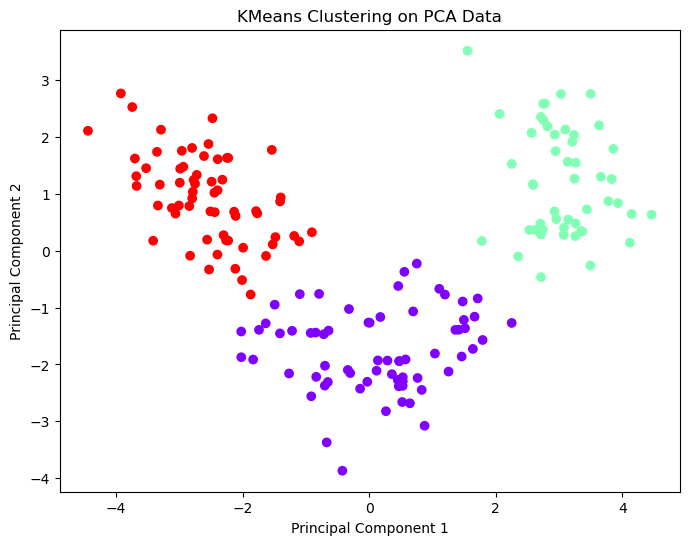

In [18]:
# --------------------------------------------
# Visualization of PCA Clusters
# --------------------------------------------
plt.figure(figsize=(8,6))

plt.scatter(pca_transformed[:,0],
            pca_transformed[:,1],
            c=pca_clusters,
            cmap='rainbow')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Clustering on PCA Data")
plt.show()

In [19]:
# ============================================
# TASK 5: COMPARISON AND ANALYSIS
# ============================================

print("\n========== COMPARISON ==========")

print("\nOriginal Data:")
print("Silhouette Score:", silhouette_original)
print("Davies-Bouldin Index:", db_original)

print("\nPCA Data:")
print("Silhouette Score:", silhouette_pca)
print("Davies-Bouldin Index:", db_pca)



========== COMPARISON ==========

Original Data:
Silhouette Score: 0.30648398324833453
Davies-Bouldin Index: 1.315707552261773

PCA Data:
Silhouette Score: 0.3402428666857789
Davies-Bouldin Index: 1.1903042789637739


In [20]:
# ============================================
# TASK 6: CONCLUSION AND INSIGHTS
# ============================================

print("\n========== CONCLUSION ==========")

print("""
1. PCA successfully reduced the dimensionality of the dataset
   while preserving most of the variance.

2. Clustering on PCA-transformed data improved visualization
   and reduced computational complexity.

3. If the silhouette score improves after PCA, it indicates
   better cluster separation.

4. PCA helps remove noise and correlated features, which can
   improve clustering performance.

5. However, dimensionality reduction may also lead to some
   information loss.

6. Use PCA when:
   - Dataset has many correlated variables
   - Visualization is needed
   - Faster computation is required

7. Use original data when:
   - Interpretability of original features is important
   - Dataset has fewer dimensions
""")


========== CONCLUSION ==========

1. PCA successfully reduced the dimensionality of the dataset
   while preserving most of the variance.

2. Clustering on PCA-transformed data improved visualization
   and reduced computational complexity.

3. If the silhouette score improves after PCA, it indicates
   better cluster separation.

4. PCA helps remove noise and correlated features, which can
   improve clustering performance.

5. However, dimensionality reduction may also lead to some
   information loss.

6. Use PCA when:
   - Dataset has many correlated variables
   - Visualization is needed
   - Faster computation is required

7. Use original data when:
   - Interpretability of original features is important
   - Dataset has fewer dimensions

